In [1]:
import glob

import cftime
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import geopandas as gpd
import regionmask

from unseen import fileio
from unseen import eva

In [2]:
def mask_ocean(ds, overlap_threshold=0.1):
    """Mask the ocean."""

    shape_gpd = gpd.read_file('/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp')
    #shape_gpd = gpd.read_file('/Users/irv033/Documents/code/shapefiles/data/australia/shapefiles_australia/australia.shp')

    shape_rgm = regionmask.from_geopandas(
        shape_gpd,
        names="AUS_NAME21",
        abbrevs="AUS_CODE21",
        name="australia"
    )
    frac = shape_rgm.mask_3D_frac_approx(ds)
    mask = frac.sel(region=0) >= overlap_threshold

    return ds.where(mask)

In [3]:
#Katherine, NT = -14.5, 132.3
#Surat, QLD = -27.2, 149.1
#Miena, TAS = -42.0, 146.7

#St George, QLD = -28.0, 148.7
#Moree, NSW = -29.5, 149.8
#Cape Grim, TAS = -40.7, 144.7
#Goondiwindi, QLD = -28.52, 150.3

def plot_cities(ax, label_color='white'):
    lats = [-14.5, -27.2, -42.0]
    lons = [132.3, 149.1, 146.7]
    cities = ['Katherine', 'Surat', 'Miena']
    offsets = {'Katherine': 0.7, 'Surat': 0.7, 'Miena': 1.3}    
    for lon, lat, city in zip(lons, lats, cities):
        ax.plot(lon, lat, 'ro', zorder=5, transform=ccrs.PlateCarree())
        ax.text(
            lon + offsets[city],
            lat,
            city,
            fontsize='large',
            color=label_color,
            transform=ccrs.PlateCarree()
        )

In [4]:
ds_fraction = fileio.open_dataset(
    '/g/data/xv83/unseen-projects/outputs/bias/data/agcd_v1-0-1_precip_weight-fraction_r005_daily_1900-2022.nc',
#    '/Users/irv033/Desktop/unseen-bias/agcd_v1-0-1_precip_weight-fraction_r005_daily_1900-2022.nc',
)
selection = {'lat': slice(-43.5, -10.5), 'lon': slice(112, 154)}
ds_fraction_coarse = ds_fraction.sel(selection).coarsen(lon=60, lat=60, boundary='trim').max()
ds_fraction_coarse['lat'] = ds_fraction_coarse['lat'] + 0.025
ds_fraction_coarse['lon'] = ds_fraction_coarse['lon'] + 0.025

In [5]:
def mask_by_pr_ob_fraction(da, threshold=0.75):
    """Mask data according to precip obs fraction"""
    
    da_selection = ds_fraction_coarse['fraction'] > threshold 
    da = da.where(da_selection)
    
    return da

In [6]:
def process_model(metric, model):
    """Process a single metric/model combination"""
    
    model_file = glob.glob(f'/g/data/xv83/unseen-projects/outputs/bias/data/{metric}_{model}-*_*_annual-jul-to-jun_AUS300i.nc')[0]
    ds_model = fileio.open_dataset(model_file)
    ds_model_stacked = ds_model.dropna('lead_time').stack({'sample': ['ensemble', 'init_date', 'lead_time']})
    da_model = mask_ocean(ds_model_stacked['tasmax'], overlap_threshold=0.01)
    gev_model = eva.fit_gev(da_model, core_dim='sample')
    gev_model = gev_model.compute()

    return gev_model

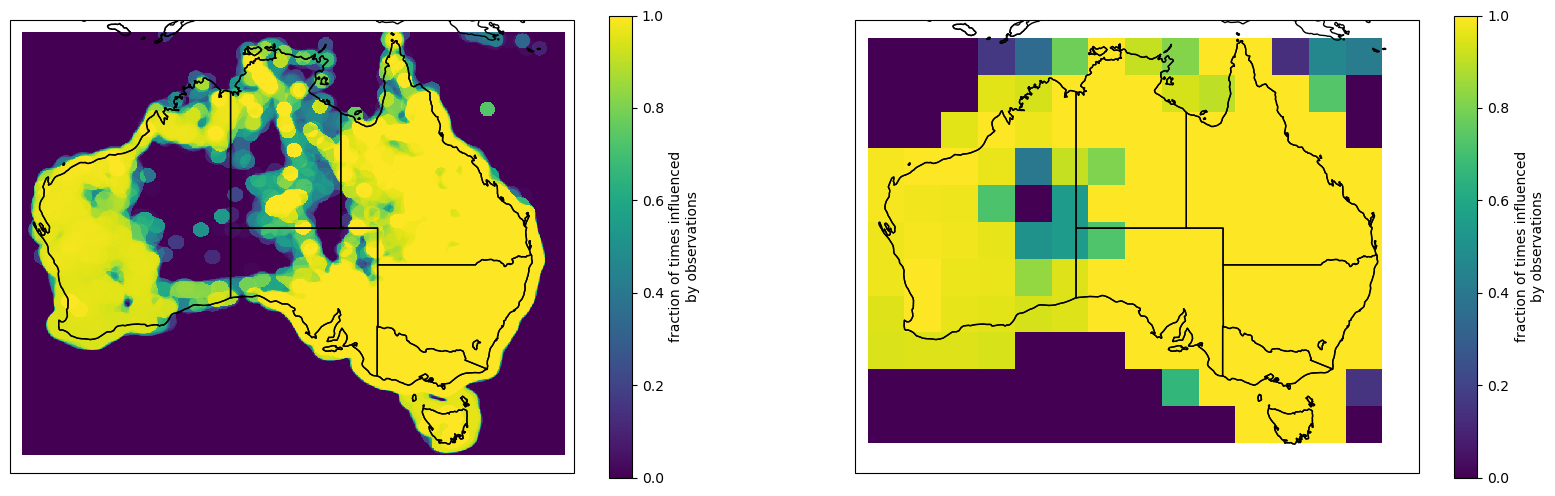

In [7]:
fig = plt.figure(figsize=[20,6])
ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())

map_extent = [111, 157, -9, -46]

im1 = ds_fraction['fraction'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree()
)
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.set_extent(map_extent, crs=ccrs.PlateCarree())

im2 = ds_fraction_coarse['fraction'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
)
#ax1.set_title("Fraction of days influenced by obs (1900-2022)")
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
ax2.set_extent(map_extent, crs=ccrs.PlateCarree())

plt.show()

## TXx

In [8]:
#txx_obs_file = '/Users/irv033/Desktop/unseen-bias/txx_AGCD-CSIRO_1901-2024_annual-jul-to-jun_AUS300i.nc'
txx_obs_file = '/g/data/xv83/unseen-projects/outputs/bias/data/txx_AGCD-CSIRO_1901-2024_annual-jul-to-jun_AUS300i.nc'
ds_obs = fileio.open_dataset(txx_obs_file)
da_obs = mask_ocean(ds_obs['tasmax'], overlap_threshold=0.01)
gev_obs = eva.fit_gev(da_obs)
gev_obs = gev_obs.compute()

In [10]:
shape_levels_dict = {
    'txx': [-0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
}
    
shape_cmap_dict = {
    'txx': 'RdBu_r'
}
    
loc_levels_dict = {
    'txx': [25, 27.5, 30, 32.5, 35, 37.5, 40, 42.5, 45, 47.5, 50, 52.5],
}
    
loc_cmap_dict = {
    'txx': 'viridis',
}

scale_levels_dict = {
    'txx': [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4.0],
}

scale_cmap_dict = {
    'txx': 'viridis'
}

In [11]:
def plot_row(gev_da, model_name, metric, fig, nrows, ncols, row_num):
    """Plot a row"""

    shape_levels = shape_levels_dict[metric]
    shape_cmap = shape_cmap_dict[metric] 
    loc_levels = loc_levels_dict[metric]  
    loc_cmap = loc_cmap_dict[metric]
    scale_levels = scale_levels_dict[metric]
    scale_cmap = scale_cmap_dict[metric]
    
    map_extent = [111, 155, -9, -45]

    index = row_num + 2 * (row_num - 1)

    ax1 = fig.add_subplot(nrows, ncols, index, projection=ccrs.PlateCarree())
    im1 = gev_da.sel({'dparams': 'c'}).plot(
        ax=ax1,
        transform=ccrs.PlateCarree(),
        cmap=shape_cmap,
        levels=shape_levels,
        extend='both',
        cbar_kwargs={'label': ' '},
    )
    plot_cities(ax1, label_color='black')
    ax1.set_title(f"Shape ({model_name})")
    ax1.coastlines()
    ax1.add_feature(cartopy.feature.STATES)
    ax1.set_extent(map_extent, crs=ccrs.PlateCarree())

    ax2 = fig.add_subplot(nrows, ncols, index + 1, projection=ccrs.PlateCarree())
    im2 = gev_da.sel({'dparams': 'loc'}).plot(
        ax=ax2,
        transform=ccrs.PlateCarree(),
        cmap=loc_cmap,
        levels=loc_levels,
        extend='both',
        cbar_kwargs={'label': ' '},
    )
    ax2.set_title(f"Location ({model_name})")
    ax2.coastlines()
    ax2.add_feature(cartopy.feature.STATES)
    ax2.set_extent(map_extent, crs=ccrs.PlateCarree())

    ax3 = fig.add_subplot(nrows, ncols, index + 2, projection=ccrs.PlateCarree())
    im3 = gev_da.sel({'dparams': 'scale'}).plot(
        ax=ax3,
        transform=ccrs.PlateCarree(),
        cmap=scale_cmap,
        levels=scale_levels,
        extend='both',
        cbar_kwargs={'label': ' '},
    )
    ax3.set_title(f"Scale ({model_name})")
    ax3.coastlines()
    ax3.add_feature(cartopy.feature.STATES)
    ax3.set_extent(map_extent, crs=ccrs.PlateCarree())

In [12]:
model_list = [
    'BCC-CSM2-MR',
    'CMCC-CM2-SR5',
    'CanESM5',
    'IPSL-CM6A-LR',
    'MIROC6',
    'MPI-ESM1-2-HR',
    'MRI-ESM2-0',
    'NorCPM1',
]   

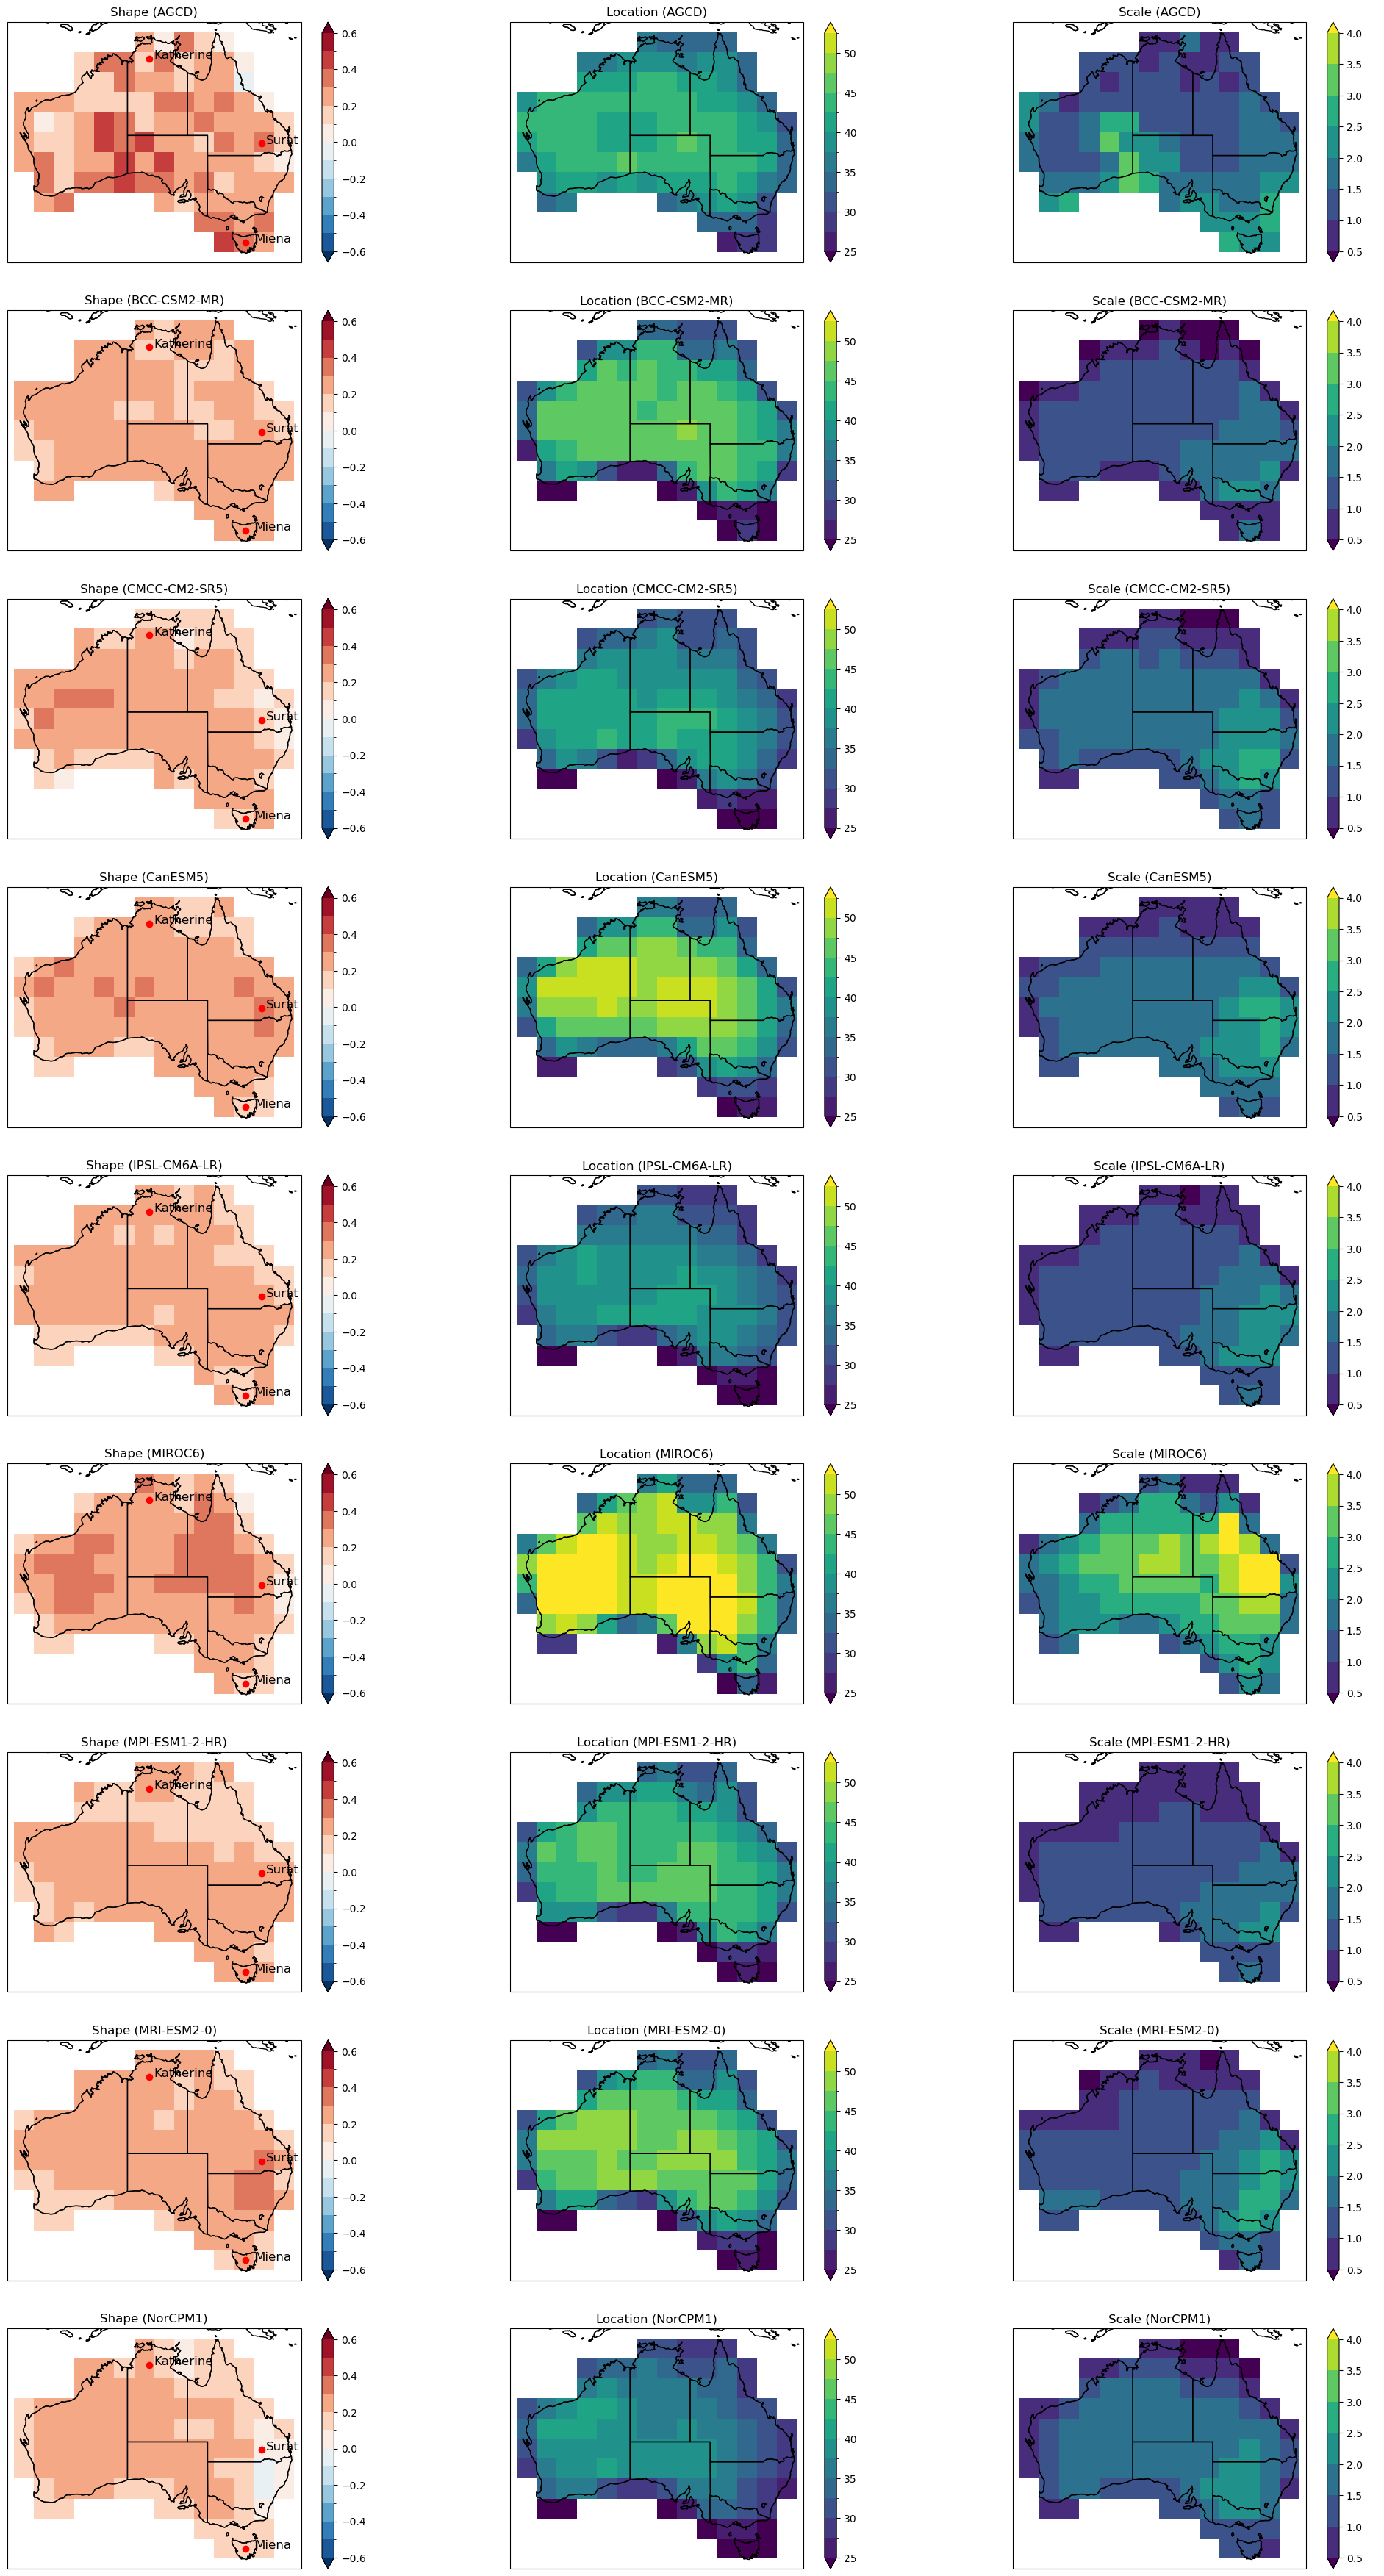

In [13]:
nmodels = len(model_list)
nrows = nmodels + 1
ncols = 3

fig = plt.figure(figsize=[25, nrows * 5])

plot_row(gev_obs, 'AGCD', 'txx', fig, nrows, ncols, 1)

for i, model in enumerate(model_list):
    gev_model = process_model('txx', model)
    plot_row(gev_model, model, 'txx', fig, nrows, ncols, i + 2)

plt.show()

In [14]:
#nmodels = len(model_list)
#nrows = nmodels + 1
#ncols = 3

#fig = plt.figure(figsize=[25, nrows * 5])

#plot_row(gev_obs, 'AGCD', fig, nrows, ncols, 1)
#
#for i, model in enumerate(model_list):
#    gev_model = process_model('txx', model)
#    plot_row(gev_model - gev_obs, model, fig, nrows, ncols, i + 2)
#
#plt.show()

## rx1day

In [16]:
rx1day_obs_file = '/Users/irv033/Desktop/unseen-bias/rx1day_AGCD-CSIRO_1901-2024_annual-jul-to-jun_AUS300i.nc'
ds_obs = fileio.open_dataset(rx1day_obs_file)
da_obs = mask_ocean(ds_obs['pr'], overlap_threshold=0.01)

In [17]:
da_obs = mask_by_pr_ob_fraction(da_obs, threshold=0.8)

In [18]:
gev_obs = eva.fit_gev(da_obs)
gev_obs = gev_obs.compute()

In [19]:
rx1day_model_file = '/Users/irv033/Desktop/unseen-bias/rx1day_CanESM5-dcppA-hindcast_196101-201701_annual-jul-to-jun_AUS300i.nc'
ds_model = fileio.open_dataset(rx1day_model_file)
ds_model_stacked = ds_model.dropna('lead_time').stack({'sample': ['ensemble', 'init_date', 'lead_time']})
da_model = mask_ocean(ds_model_stacked['pr'], overlap_threshold=0.01)

In [20]:
gev_model = eva.fit_gev(da_model, core_dim='sample')
gev_model = gev_model.compute()

In [21]:
gev_diff = gev_model - gev_obs

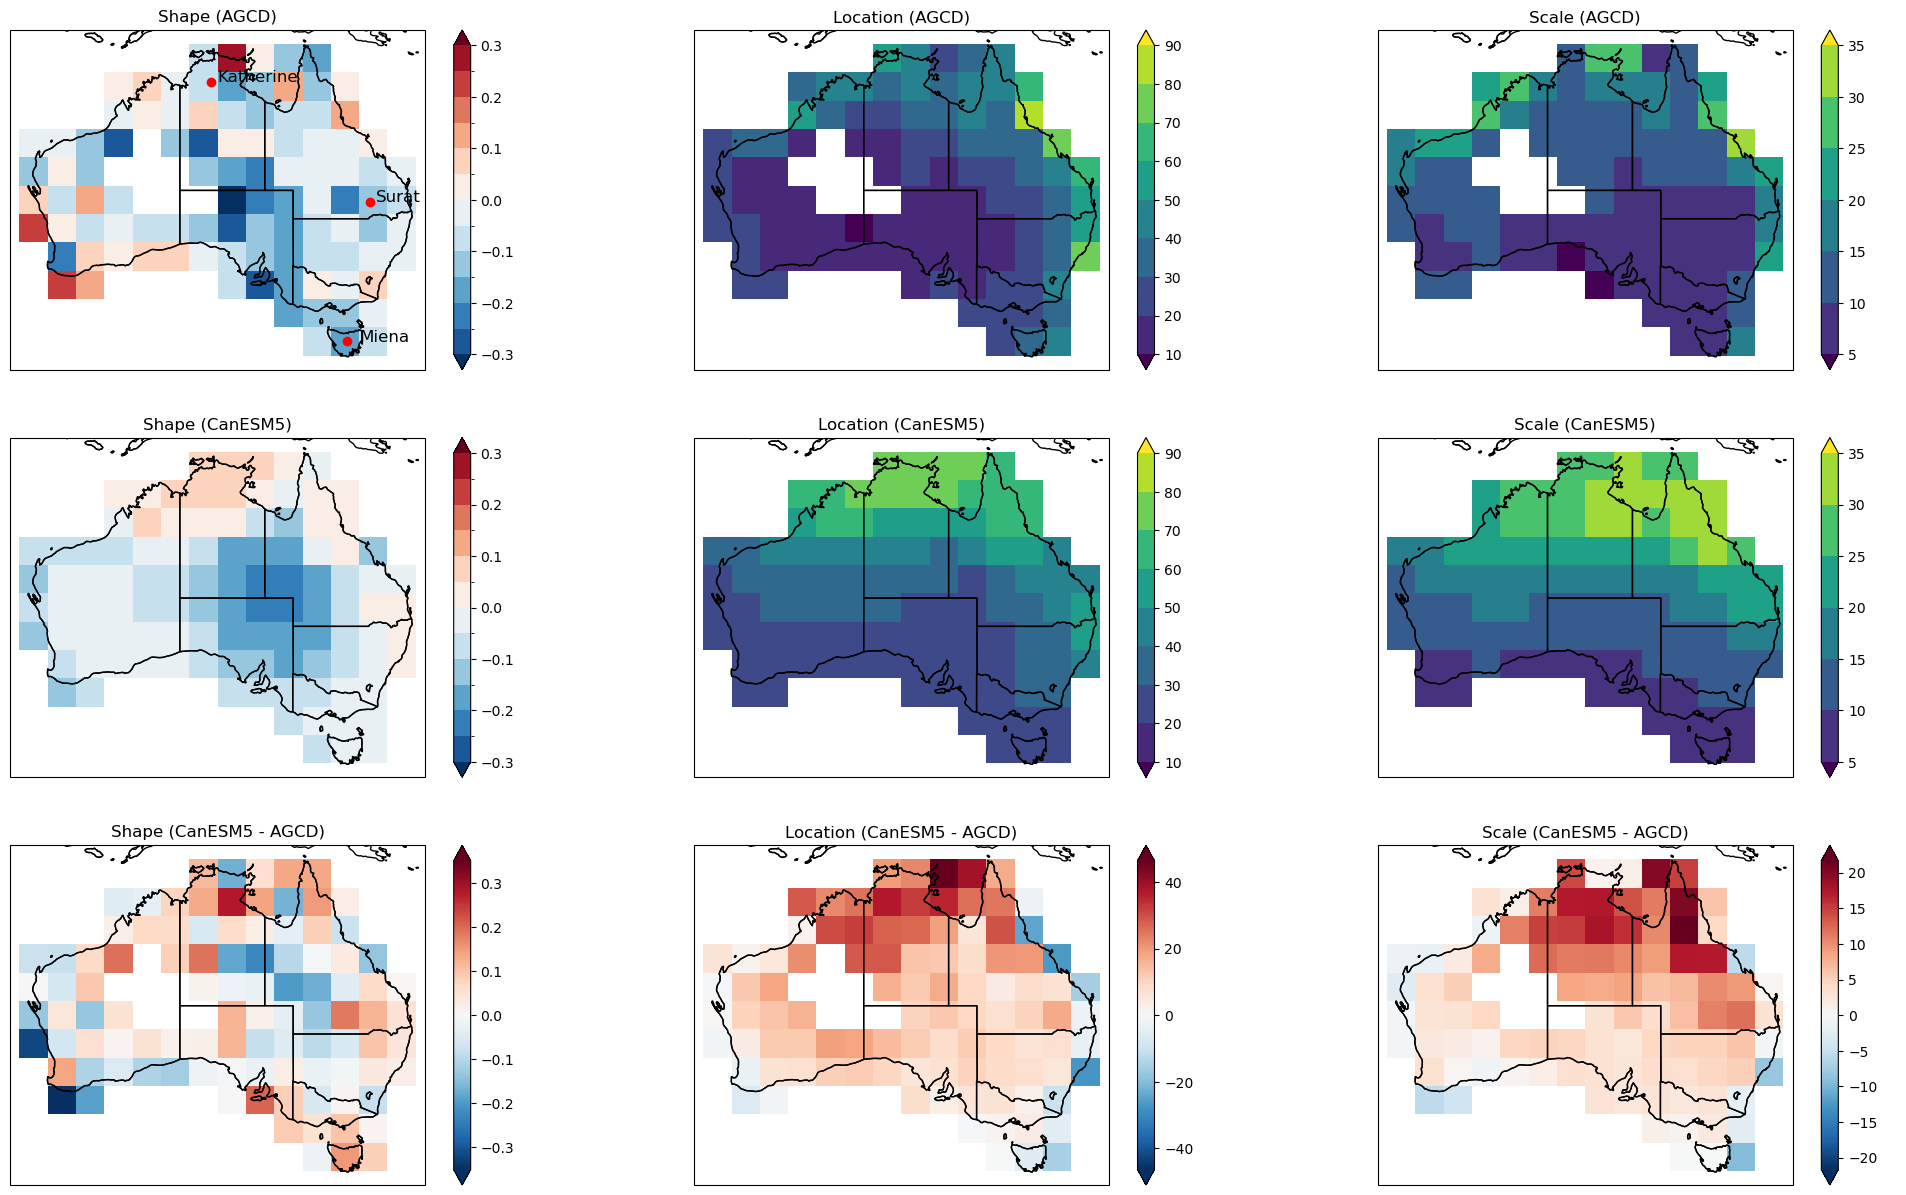

In [22]:
fig = plt.figure(figsize=[25, 15])
ax1 = fig.add_subplot(331, projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(332, projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(333, projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(334, projection=ccrs.PlateCarree())
ax5 = fig.add_subplot(335, projection=ccrs.PlateCarree())
ax6 = fig.add_subplot(336, projection=ccrs.PlateCarree())
ax7 = fig.add_subplot(337, projection=ccrs.PlateCarree())
ax8 = fig.add_subplot(338, projection=ccrs.PlateCarree())
ax9 = fig.add_subplot(339, projection=ccrs.PlateCarree())

shape_levels = [-0.3, -0.25, -0.2, -0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
shape_cmap = 'RdBu_r'
loc_levels = [10, 20, 30, 40, 50, 60, 70, 80, 90]
loc_cmap = 'viridis'
scale_levels = [5, 10, 15, 20, 25, 30, 35]
scale_cmap = 'viridis'

map_extent = [111, 155, -9, -45]

# AGCD

im1 = gev_obs.sel({'dparams': 'c'}).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap=shape_cmap,
    levels=shape_levels,
    extend='both',
    cbar_kwargs={'label': ' '},
)
plot_cities(ax1, label_color='black')
ax1.set_title("Shape (AGCD)")
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.set_extent(map_extent, crs=ccrs.PlateCarree())

im2 = gev_obs.sel({'dparams': 'loc'}).plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap=loc_cmap,
    levels=loc_levels,
    extend='both',
    cbar_kwargs={'label': ' '},
)
ax2.set_title("Location (AGCD)")
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
ax2.set_extent(map_extent, crs=ccrs.PlateCarree())

im3 = gev_obs.sel({'dparams': 'scale'}).plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cmap=scale_cmap,
    levels=scale_levels,
    extend='both',
    cbar_kwargs={'label': ' '},
)
ax3.set_title("Scale (AGCD)")
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
ax3.set_extent(map_extent, crs=ccrs.PlateCarree())

# Model

im4 = gev_model.sel({'dparams': 'c'}).plot(
    ax=ax4,
    transform=ccrs.PlateCarree(),
    cmap=shape_cmap,
    levels=shape_levels,
    extend='both',
    cbar_kwargs={'label': ' '},
)
ax4.set_title("Shape (CanESM5)")
ax4.coastlines()
ax4.add_feature(cartopy.feature.STATES)
ax4.set_extent(map_extent, crs=ccrs.PlateCarree())

im5 = gev_model.sel({'dparams': 'loc'}).plot(
    ax=ax5,
    transform=ccrs.PlateCarree(),
    cmap=loc_cmap,
    levels=loc_levels,
    extend='both',
    cbar_kwargs={'label': ' '},
)
ax5.set_title("Location (CanESM5)")
ax5.coastlines()
ax5.add_feature(cartopy.feature.STATES)
ax5.set_extent(map_extent, crs=ccrs.PlateCarree())

im6 = gev_model.sel({'dparams': 'scale'}).plot(
    ax=ax6,
    transform=ccrs.PlateCarree(),
    cmap=scale_cmap,
    levels=scale_levels,
    extend='both',
    cbar_kwargs={'label': ' '},
)
ax6.set_title("Scale (CanESM5)")
ax6.coastlines()
ax6.add_feature(cartopy.feature.STATES)
ax6.set_extent(map_extent, crs=ccrs.PlateCarree())

# Difference (model - obs)

im7 = gev_diff.sel({'dparams': 'c'}).plot(
    ax=ax7,
    transform=ccrs.PlateCarree(),
    extend='both',
    cbar_kwargs={'label': ' '},
)
ax7.set_title("Shape (CanESM5 - AGCD)")
ax7.coastlines()
ax7.add_feature(cartopy.feature.STATES)
ax7.set_extent(map_extent, crs=ccrs.PlateCarree())

im8 = gev_diff.sel({'dparams': 'loc'}).plot(
    ax=ax8,
    transform=ccrs.PlateCarree(),
    extend='both',
    cbar_kwargs={'label': ' '},
)
ax8.set_title("Location (CanESM5 - AGCD)")
ax8.coastlines()
ax8.add_feature(cartopy.feature.STATES)
ax8.set_extent(map_extent, crs=ccrs.PlateCarree())

im9 = gev_diff.sel({'dparams': 'scale'}).plot(
    ax=ax9,
    transform=ccrs.PlateCarree(),
    extend='both',
    cbar_kwargs={'label': ' '},
)
ax9.set_title("Scale (CanESM5 - AGCD)")
ax9.coastlines()
ax9.add_feature(cartopy.feature.STATES)
ax9.set_extent(map_extent, crs=ccrs.PlateCarree())

plt.show()